# AUS Funding Exploratory Data Analysis (EDA)

This notebook provides a reusable EDA workflow for Australian funding data.

**Default dataset:** `../data/clean/AnnualFundingAUS2019-2026.xlsx`

> This dataset contains funding settings by **Year**, **Field of Education (FOE)**, and **Funding Cluster**, including the **Maximum Student Contribution** and **Commonwealth Contribution**.

> The summary views below focus on **per-student funding amounts** rather than national funding totals, because each row represents a funding schedule entry rather than an enrollment-weighted total.

> You can change `dataset_path` in the next cell if you want to analyze a different AUS funding file.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

dataset_path = Path("../data/clean/AnnualFundingAUS2019-2026.xlsx")
fallback_path = Path("../data/clean/AnnualFundingAUS2019-2026.csv")

if not dataset_path.exists() and not fallback_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {dataset_path.resolve()} or {fallback_path.resolve()}"
    )

try:
    if dataset_path.exists():
        df = pd.read_excel(dataset_path)
    else:
        df = pd.read_csv(fallback_path)
        dataset_path = fallback_path
except ImportError:
    df = pd.read_csv(fallback_path)
    dataset_path = fallback_path
except UnicodeDecodeError:
    df = pd.read_csv(fallback_path, encoding="latin-1")
    dataset_path = fallback_path

print(f"Loaded {dataset_path.name}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
display(df.head())

Loaded AnnualFundingAUS2019-2026.xlsx
Rows: 3,484 | Columns: 6


,Year,FOE,FOE_Description,FundingCluster,MaximumStudentContribution,CommonwealthContribution
0,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 3,6566,10630
1,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 5,6566,13073
2,2019,80100,Accounting,Funding Cluster 1,10958,2160
3,2019,80101,Accounting,Funding Cluster 1,10958,2160
4,2019,80300,Business and Management,Funding Cluster 1,10958,2160


## 1. Inspect Data Structure

Review the columns, data types, years, funding clusters, and the overall structure of the AUS funding dataset.

In [2]:
print("Column names:")
print(df.columns.tolist())

money_cols = ["MaximumStudentContribution", "CommonwealthContribution"]
for col in ["Year", "FOE", *money_cols]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "Year" in df.columns:
    year_sequence = sorted(df["Year"].dropna().astype(int).unique().tolist())
else:
    year_sequence = []

if "FundingCluster" in df.columns:
    cluster_order = df["FundingCluster"].dropna().astype(str).drop_duplicates().tolist()
    df["FundingCluster"] = pd.Categorical(
        df["FundingCluster"].astype(str),
        categories=cluster_order,
        ordered=True,
    )
else:
    cluster_order = []

print(f"\nYears covered: {year_sequence}")
if cluster_order:
    print(f"\nFunding clusters ({len(cluster_order)}): {cluster_order}")

if "FOE_Description" in df.columns:
    print(f"\nUnique FOE descriptions: {df['FOE_Description'].nunique():,}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nShape: {df.shape}")
print("\nDataset info:")
df.info()

print("\nPreview:")
display(df.head())

Column names:
['Year', 'FOE', 'FOE_Description', 'FundingCluster', 'MaximumStudentContribution', 'CommonwealthContribution']

Years covered: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

Funding clusters (8): ['Funding Cluster 3', 'Funding Cluster 5', 'Funding Cluster 1', 'Funding Cluster 2', 'Funding Cluster 4', 'Funding Cluster 6', 'Funding Cluster 7', 'Funding Cluster 8']

Unique FOE descriptions: 438

Data types:


,dtype
Year,int64
FOE,float64
FOE_Description,str
FundingCluster,category
MaximumStudentContribution,int64
CommonwealthContribution,int64



Shape: (3484, 6)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 3484 entries, 0 to 3483
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Year                        3484 non-null   int64   
 1   FOE                         3482 non-null   float64 
 2   FOE_Description             3484 non-null   str     
 3   FundingCluster              3484 non-null   category
 4   MaximumStudentContribution  3484 non-null   int64   
 5   CommonwealthContribution    3484 non-null   int64   
dtypes: category(1), float64(1), int64(3), str(1)
memory usage: 140.0 KB

Preview:


,Year,FOE,FOE_Description,FundingCluster,MaximumStudentContribution,CommonwealthContribution
0,2019,90701.0,Psychology (Not professional pathway psycholog...,Funding Cluster 3,6566,10630
1,2019,90701.0,Psychology (Not professional pathway psycholog...,Funding Cluster 5,6566,13073
2,2019,80100.0,Accounting,Funding Cluster 1,10958,2160
3,2019,80101.0,Accounting,Funding Cluster 1,10958,2160
4,2019,80300.0,Business and Management,Funding Cluster 1,10958,2160


## 2. Clean Missing Values and Duplicates

Check for missing values and duplicate rows, then create a cleaned copy for analysis.

In [3]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
if missing_summary.empty:
    display(pd.DataFrame({"message": ["No missing values found"]}))
else:
    display(missing_summary.to_frame("missing_count"))

duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")

df_clean = df.drop_duplicates().copy()
for col in money_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

if all(col in df_clean.columns for col in money_cols):
    df_clean["TotalFundingPerStudent"] = df_clean[money_cols].sum(axis=1)

df_clean_no_total = df_clean.copy()
df_clean["FOE_Label"] = (
    df_clean["FOE_Description"].astype(str)
    if "FOE_Description" in df_clean.columns
    else df_clean["FOE"].astype(str)
)

print(f"Shape after cleaning: {df_clean.shape}")

Missing values by column:


,missing_count
FOE,2


Duplicate rows: 0
Shape after cleaning: (3484, 8)


## 3. Compute Summary Statistics

Summarize the funding data across years, funding clusters, and fields of education.

In [4]:
numeric_cols = [
    col
    for col in ["Year", "FOE", "MaximumStudentContribution", "CommonwealthContribution", "TotalFundingPerStudent"]
    if col in df_clean.columns
]
categorical_cols = [col for col in ["FundingCluster", "FOE_Description"] if col in df_clean.columns]

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)

if numeric_cols:
    display(df_clean[numeric_cols].describe().T)
else:
    print("No numeric columns available for summary statistics.")

if {"Year", "FundingCluster", "TotalFundingPerStudent"}.issubset(df_clean.columns):
    cluster_year = (
        df_clean.groupby(["Year", "FundingCluster"], observed=True)[["MaximumStudentContribution", "CommonwealthContribution", "TotalFundingPerStudent"]]
        .mean()
        .reset_index()
    )
    display(cluster_year.head())

    latest_year = int(df_clean["Year"].max())
    latest_cluster_ranking = (
        cluster_year[cluster_year["Year"] == latest_year]
        .sort_values("TotalFundingPerStudent", ascending=False)
    )
    print(f"\nAverage funding by cluster in {latest_year}:")
    display(latest_cluster_ranking)

    if "FOE_Description" in df_clean.columns:
        top_foe_latest = (
            df_clean[df_clean["Year"] == latest_year][["FOE_Description", "FundingCluster", "TotalFundingPerStudent"]]
            .sort_values("TotalFundingPerStudent", ascending=False)
            .head(10)
        )
        print(f"\nTop FOE descriptions by combined per-student funding in {latest_year}:")
        display(top_foe_latest)
else:
    print("Year, FundingCluster, and TotalFundingPerStudent are required for grouped summaries.")

Numeric columns (5): ['Year', 'FOE', 'MaximumStudentContribution', 'CommonwealthContribution', 'TotalFundingPerStudent']
Categorical columns (2): ['FundingCluster', 'FOE_Description']


,count,mean,std,min,25%,50%,75%,max
Year,3484.0,2022.541332,2.280190,2019.0,2021.0,2023.0,2025.0,2026.0
FOE,3482.0,61827.922458,31085.223996,10100.0,31199.0,61300.0,90513.0,129999.0
MaximumStudentContribution,3484.0,10075.811711,3635.042046,0.0,8021.0,9359.0,11800.0,17399.0
CommonwealthContribution,3484.0,12750.303961,8040.991436,1100.0,2198.0,14915.0,18292.0,32400.0
TotalFundingPerStudent,3484.0,22826.115672,6293.312321,12574.0,17960.0,22137.0,25435.0,45958.0


,Year,FundingCluster,MaximumStudentContribution,CommonwealthContribution,TotalFundingPerStudent
0,2019,Funding Cluster 3,8391.128713,10630.0,19021.128713
1,2019,Funding Cluster 5,7479.096154,13073.0,20552.096154
2,2019,Funding Cluster 1,10958.000000,2160.0,13118.000000
3,2019,Funding Cluster 2,6566.000000,6008.0,12574.000000
4,2019,Funding Cluster 4,6566.000000,11061.0,17627.000000



Average funding by cluster in 2026:


,Year,FundingCluster,MaximumStudentContribution,CommonwealthContribution,TotalFundingPerStudent
41,2026,Funding Cluster 4,10067.382353,32400.0,42467.382353
37,2026,Funding Cluster 3,8876.268116,19497.0,28373.268116
40,2026,Funding Cluster 2,8626.240876,15898.0,24524.240876
38,2026,Funding Cluster 5,0.000000,18716.0,18716.000000
39,2026,Funding Cluster 1,17399.000000,1316.0,18715.000000



Top FOE descriptions by combined per-student funding in 2026:


,FOE_Description,FundingCluster,TotalFundingPerStudent
3473,"Medical Studies, n.e.c.",Funding Cluster 4,45958
3469,Anaesthesiology,Funding Cluster 4,45958
3470,Radiology,Funding Cluster 4,45958
3471,Internal Medicine,Funding Cluster 4,45958
3468,Paediatrics,Funding Cluster 4,45958
3477,Dental Technology,Funding Cluster 4,45958
3478,"Dental Studies, n.e.c.",Funding Cluster 4,45958
3481,Veterinary Assisting,Funding Cluster 4,45958
3476,Dental Assisting,Funding Cluster 4,45958
3465,Surgery,Funding Cluster 4,45958


## 4. Visualize AUS Funding Trends

Plot average combined funding over time, compare funding-cluster trends with example areas of study, and show Tukey box plots by cluster.

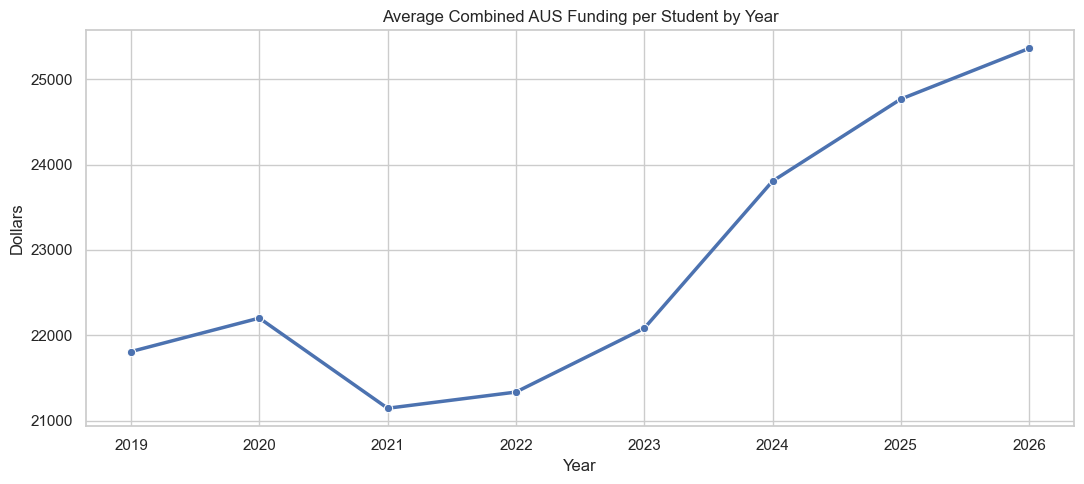

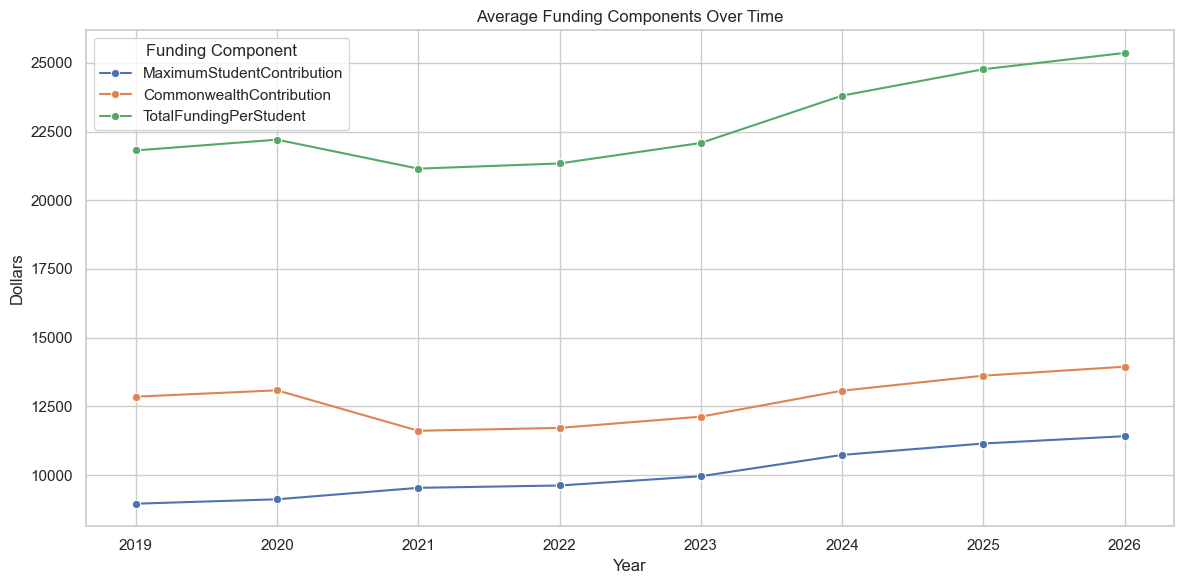

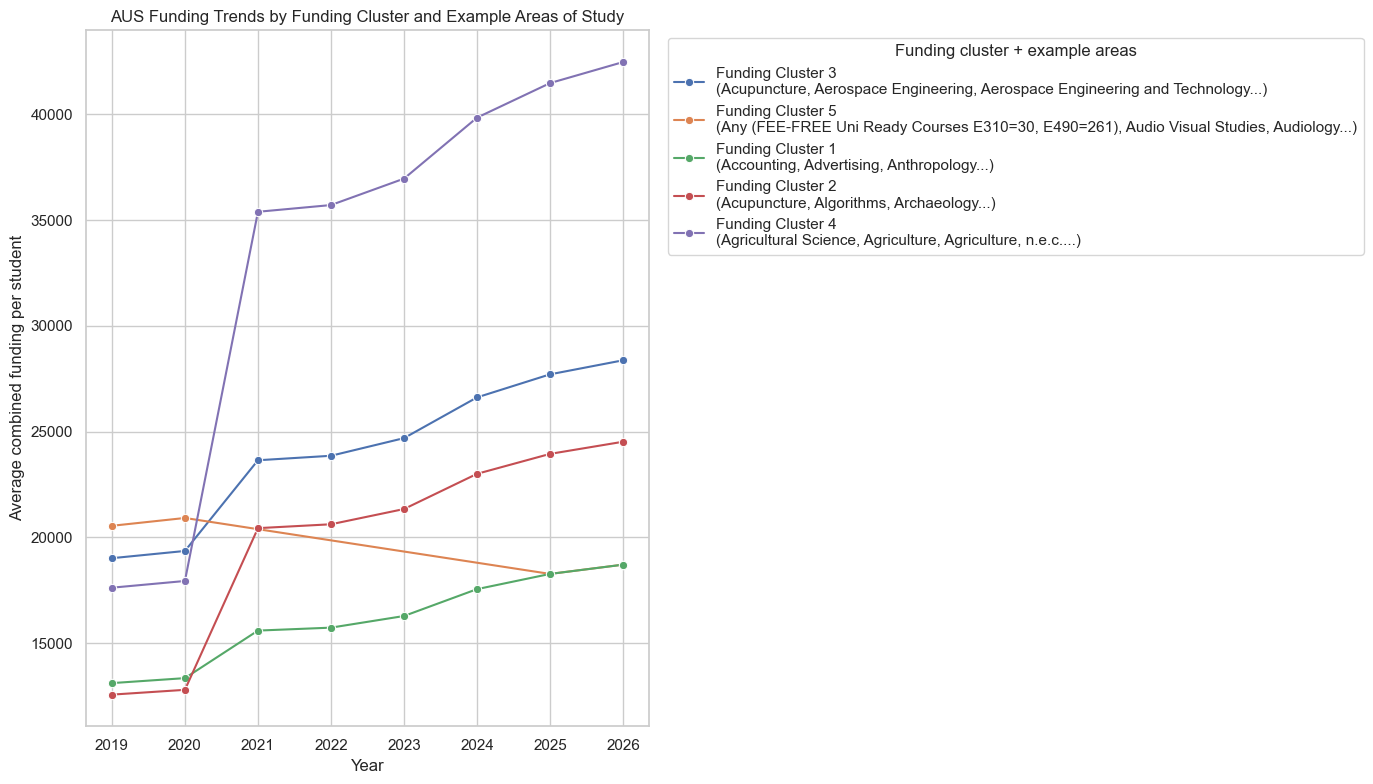

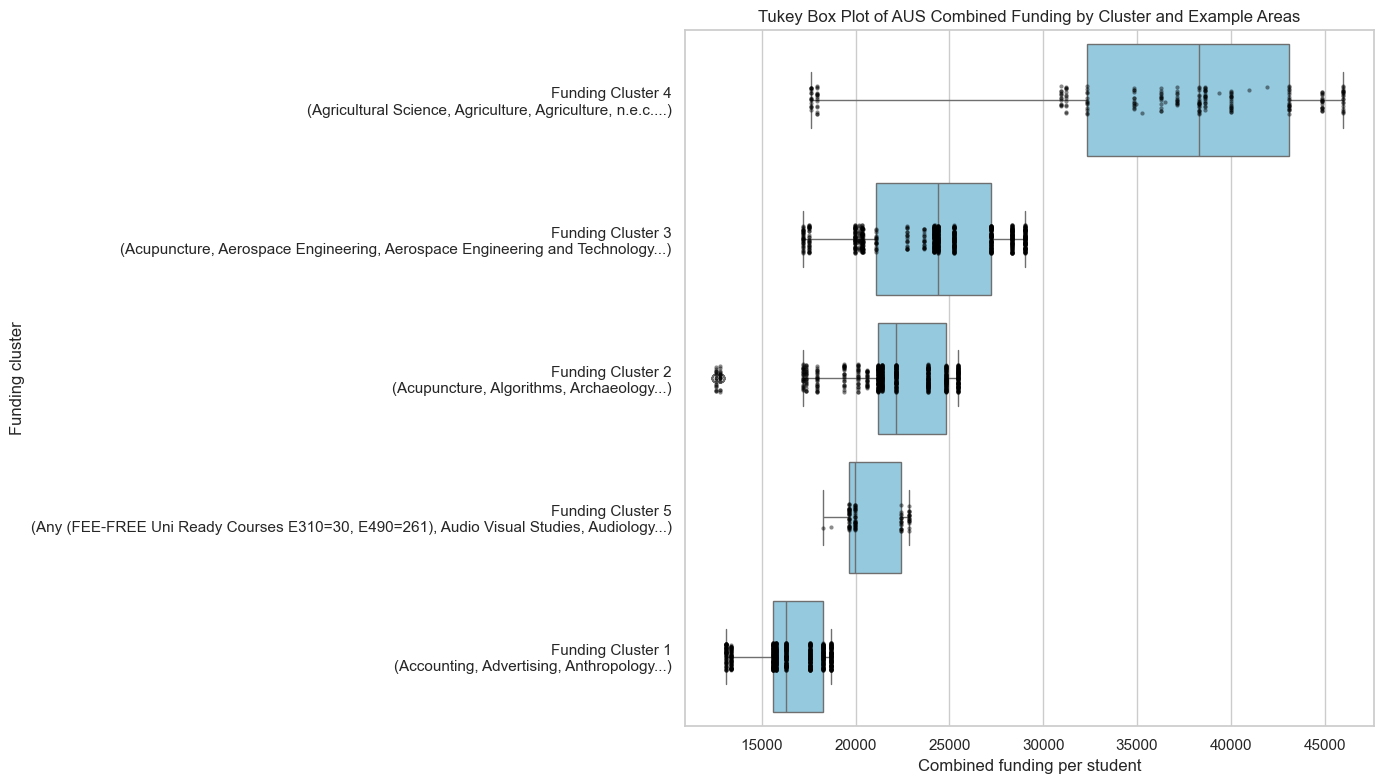

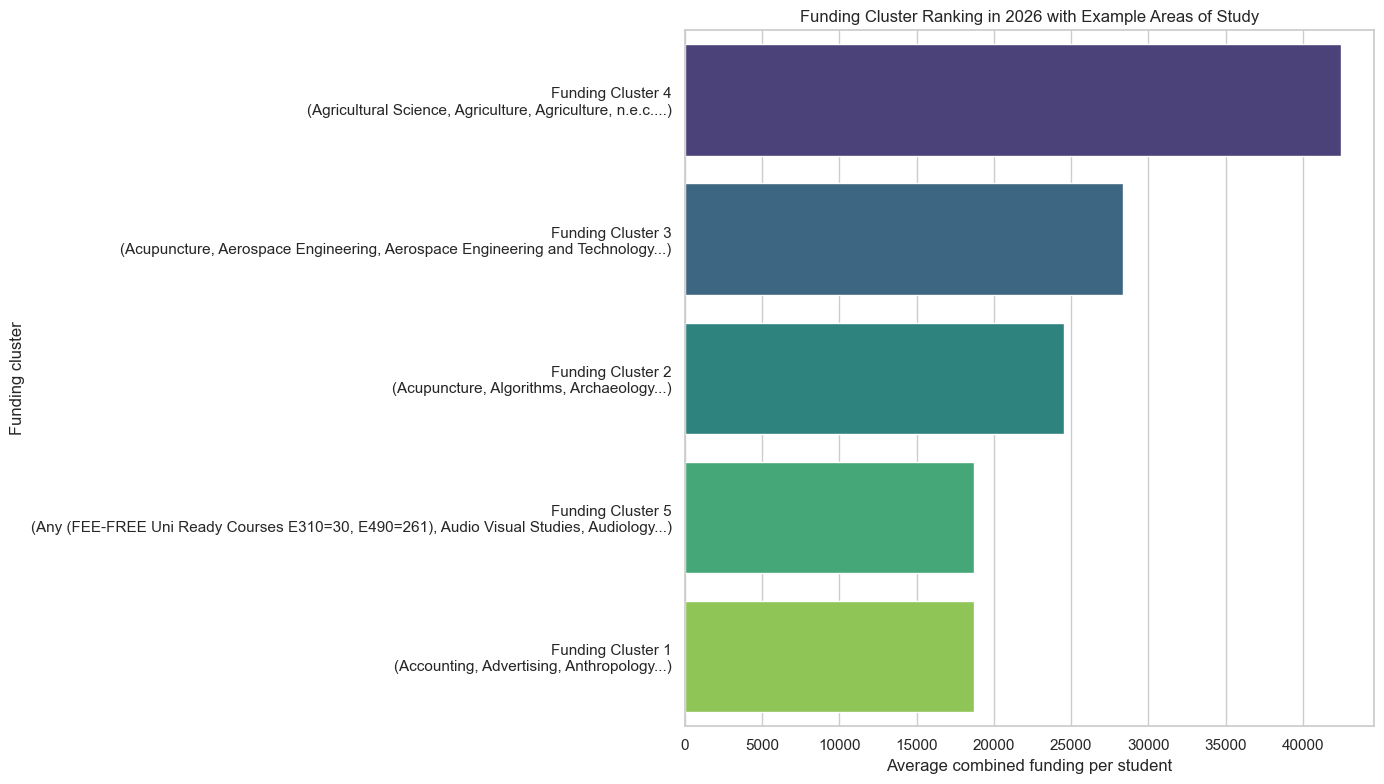

In [10]:
if {"Year", "FundingCluster", "TotalFundingPerStudent"}.issubset(df_clean.columns):
    overall_yearly_summary = (
        df_clean.groupby("Year", observed=True)[["MaximumStudentContribution", "CommonwealthContribution", "TotalFundingPerStudent"]]
        .mean()
        .reset_index()
    )

    cluster_year = (
        df_clean.groupby(["Year", "FundingCluster"], observed=True)["TotalFundingPerStudent"]
        .mean()
        .reset_index()
    )

    latest_year = int(df_clean["Year"].max())
    latest_cluster_ranking = cluster_year[cluster_year["Year"] == latest_year].sort_values(
        "TotalFundingPerStudent", ascending=False
    )
    cluster_order_for_plot = latest_cluster_ranking["FundingCluster"].astype(str).tolist()

    def summarize_areas(series, max_items=3):
        unique_areas = sorted(pd.unique(series.astype(str)))
        preview = ", ".join(unique_areas[:max_items])
        return preview + ("..." if len(unique_areas) > max_items else "")

    if "FOE_Label" in df_clean.columns:
        cluster_area_examples = (
            df_clean[["FundingCluster", "FOE_Label"]]
            .dropna(subset=["FundingCluster", "FOE_Label"])
            .assign(
                FundingCluster=lambda d: d["FundingCluster"].astype(str).str.strip(),
                FOE_Label=lambda d: d["FOE_Label"].astype(str).str.strip(),
            )
            .drop_duplicates()
            .groupby("FundingCluster", observed=True)["FOE_Label"]
            .apply(summarize_areas)
            .to_dict()
        )
    else:
        cluster_area_examples = {}

    cluster_label_map = {
        cluster: (
            f"{cluster}\n({cluster_area_examples[cluster]})"
            if cluster in cluster_area_examples
            else cluster
        )
        for cluster in cluster_order_for_plot
    }
    cluster_label_order = [cluster_label_map.get(cluster, cluster) for cluster in cluster_order_for_plot]

    cluster_year_labeled = cluster_year.assign(
        ClusterLabel=cluster_year["FundingCluster"].astype(str).map(cluster_label_map)
    )
    latest_cluster_ranking_labeled = latest_cluster_ranking.assign(
        ClusterLabel=latest_cluster_ranking["FundingCluster"].astype(str).map(cluster_label_map)
    )
    df_clean_labeled = df_clean.assign(
        ClusterLabel=df_clean["FundingCluster"].astype(str).map(cluster_label_map)
    )

    plt.figure(figsize=(11, 5))
    sns.lineplot(data=overall_yearly_summary, x="Year", y="TotalFundingPerStudent", marker="o", linewidth=2.5)
    plt.title("Average Combined AUS Funding per Student by Year")
    plt.ylabel("Dollars")
    plt.tight_layout()
    plt.show()

    components_long = overall_yearly_summary.melt(
        id_vars="Year",
        var_name="Funding Component",
        value_name="Average Amount",
    )

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=components_long, x="Year", y="Average Amount", hue="Funding Component", marker="o")
    plt.title("Average Funding Components Over Time")
    plt.ylabel("Dollars")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 8))
    sns.lineplot(data=cluster_year_labeled, x="Year", y="TotalFundingPerStudent", hue="ClusterLabel", marker="o")
    plt.title("AUS Funding Trends by Funding Cluster and Example Areas of Study")
    plt.ylabel("Average combined funding per student")
    plt.legend(title="Funding cluster + example areas", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 8))
    sns.boxplot(
        data=df_clean_labeled,
        x="TotalFundingPerStudent",
        y="ClusterLabel",
        order=cluster_label_order,
        whis=1.5,
        color="skyblue",
    )
    sns.stripplot(
        data=df_clean_labeled,
        x="TotalFundingPerStudent",
        y="ClusterLabel",
        order=cluster_label_order,
        color="black",
        alpha=0.45,
        size=3,
    )
    plt.title("Tukey Box Plot of AUS Combined Funding by Cluster and Example Areas")
    plt.xlabel("Combined funding per student")
    plt.ylabel("Funding cluster")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 8))
    sns.barplot(
        data=latest_cluster_ranking_labeled,
        x="TotalFundingPerStudent",
        y="ClusterLabel",
        hue="ClusterLabel",
        order=cluster_label_order,
        palette="viridis",
        legend=False,
    )
    plt.title(f"Funding Cluster Ranking in {latest_year} with Example Areas of Study")
    plt.xlabel("Average combined funding per student")
    plt.ylabel("Funding cluster")
    plt.tight_layout()
    plt.show()
else:
    print("The required columns for AUS funding visualizations are not available.")

## 5. Explore Correlations Across Funding Components

Check how the student contribution, Commonwealth contribution, and combined funding move together.

In [ ]:
corr_cols = [
    col
    for col in ["Year", "MaximumStudentContribution", "CommonwealthContribution", "TotalFundingPerStudent"]
    if col in df_clean.columns
]

if len(corr_cols) >= 2:
    corr_matrix = df_clean[corr_cols].corr(numeric_only=True)
    display(corr_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Between AUS Funding Components")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numeric funding columns are needed to compute correlations.")

## 6. Identify Fast-Changing and Unusual Funding Clusters

Measure how average combined funding changed from the earliest available year to the latest available year for each funding cluster and flag unusually large movements.

,FundingCluster,First Year,Last Year,First Average Funding,Last Average Funding,Absolute Change,Percent Change,Coverage,Potential Outlier
4,Funding Cluster 4,2019,2026,17627.000000,42467.382353,24840.382353,140.92,Full span,True
3,Funding Cluster 2,2019,2026,12574.000000,24524.240876,11950.240876,95.04,Full span,False
0,Funding Cluster 3,2019,2026,19021.128713,28373.268116,9352.139403,49.17,Full span,False
2,Funding Cluster 1,2019,2026,13118.000000,18715.000000,5597.000000,42.67,Full span,False
7,Funding Cluster 8,2019,2020,33768.000000,34374.853659,606.853659,1.80,Partial span,False
6,Funding Cluster 7,2019,2020,27945.000000,28447.000000,502.000000,1.80,Partial span,False
5,Funding Cluster 6,2019,2020,21162.000000,21542.000000,380.000000,1.80,Partial span,False
1,Funding Cluster 5,2019,2026,20552.096154,18716.000000,-1836.096154,-8.93,Full span,False


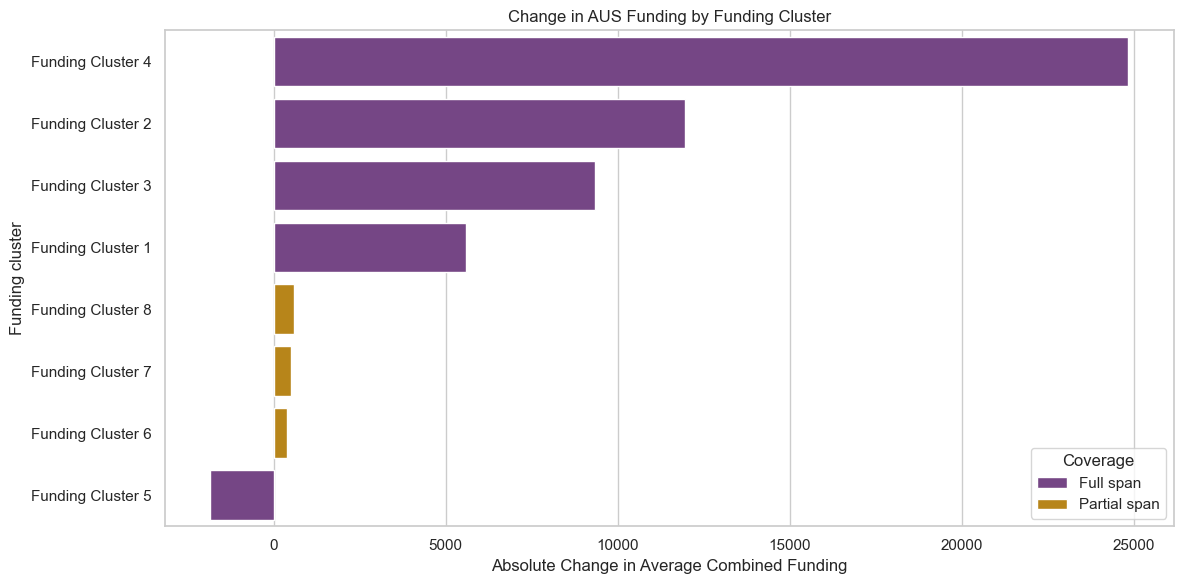

Outlier bounds for absolute change: lower=-13823.75, upper=24296.91

Potential outliers in funding-cluster change:


,FundingCluster,First Year,Last Year,First Average Funding,Last Average Funding,Absolute Change,Percent Change,Coverage,Potential Outlier
4,Funding Cluster 4,2019,2026,17627.0,42467.382353,24840.382353,140.92,Full span,True


In [6]:
if {"Year", "FundingCluster", "TotalFundingPerStudent"}.issubset(df_clean.columns):
    cluster_year_growth = (
        df_clean.groupby(["Year", "FundingCluster"], observed=True)["TotalFundingPerStudent"]
        .mean()
        .reset_index()
    )

    growth_rows = []
    ordered_years = sorted(cluster_year_growth["Year"].dropna().unique().tolist())

    for cluster, group in cluster_year_growth.groupby("FundingCluster", observed=True):
        group = group.sort_values("Year").dropna(subset=["TotalFundingPerStudent"])

        if group.empty:
            continue

        first_row = group.iloc[0]
        last_row = group.iloc[-1]
        first_value = float(first_row["TotalFundingPerStudent"])
        last_value = float(last_row["TotalFundingPerStudent"])
        absolute_change = last_value - first_value
        percent_change = (absolute_change / first_value * 100) if first_value != 0 else np.nan

        growth_rows.append({
            "FundingCluster": str(cluster),
            "First Year": int(first_row["Year"]),
            "Last Year": int(last_row["Year"]),
            "First Average Funding": first_value,
            "Last Average Funding": last_value,
            "Absolute Change": absolute_change,
            "Percent Change": round(percent_change, 2) if pd.notna(percent_change) else np.nan,
        })

    growth_df = pd.DataFrame(growth_rows).sort_values("Absolute Change", ascending=False)
    growth_df["Coverage"] = np.where(
        (growth_df["First Year"] == ordered_years[0]) & (growth_df["Last Year"] == ordered_years[-1]),
        "Full span",
        "Partial span",
    )

    q1 = growth_df["Absolute Change"].quantile(0.25)
    q3 = growth_df["Absolute Change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    growth_df["Potential Outlier"] = ~growth_df["Absolute Change"].between(lower, upper, inclusive="both")

    display(growth_df)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=growth_df.sort_values("Absolute Change", ascending=False),
        x="Absolute Change",
        y="FundingCluster",
        hue="Coverage",
        dodge=False,
        palette={"Full span": "#7a3b8f", "Partial span": "#d18f00"},
    )
    plt.title("Change in AUS Funding by Funding Cluster")
    plt.xlabel("Absolute Change in Average Combined Funding")
    plt.ylabel("Funding cluster")
    plt.tight_layout()
    plt.show()

    print(f"Outlier bounds for absolute change: lower={lower:.2f}, upper={upper:.2f}")
    print("\nPotential outliers in funding-cluster change:")
    display(growth_df[growth_df["Potential Outlier"]])
else:
    print("Year, FundingCluster, and TotalFundingPerStudent are required for growth analysis.")

## 7. Separate Tukey Box Plots by Funding Cluster

Show one independent Tukey box plot for each AUS funding cluster, based on its combined per-student funding values across years and FOE descriptions.

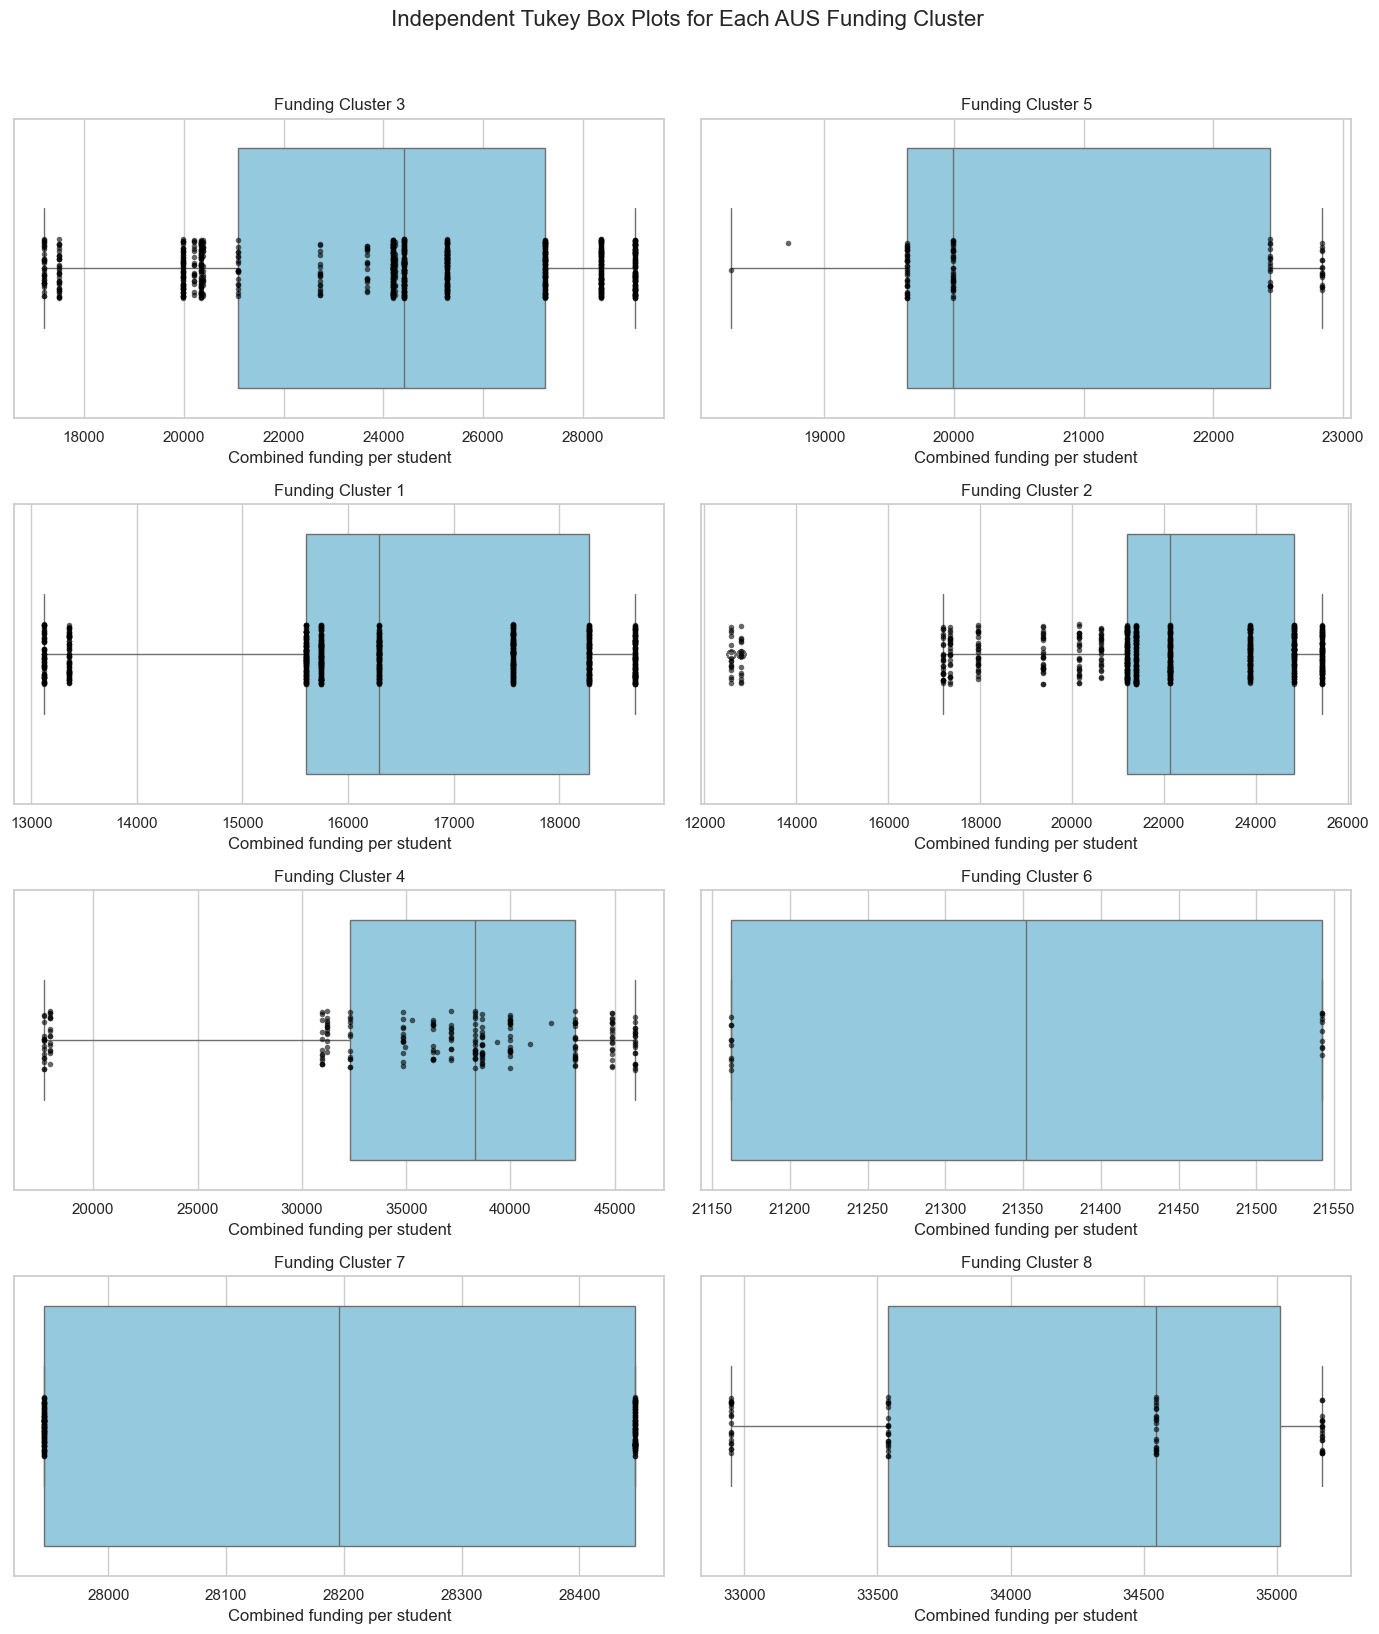

In [7]:
if {"FundingCluster", "TotalFundingPerStudent"}.issubset(df_clean.columns):
    clusters = df_clean["FundingCluster"].dropna().astype(str).unique().tolist()
    n_cols = 2
    n_rows = (len(clusters) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax, cluster in zip(axes, clusters):
        cluster_values = df_clean.loc[
            df_clean["FundingCluster"].astype(str) == cluster,
            "TotalFundingPerStudent",
        ].dropna()

        sns.boxplot(x=cluster_values, ax=ax, whis=1.5, color="skyblue")
        sns.stripplot(x=cluster_values, ax=ax, color="black", alpha=0.6, size=4)
        ax.set_title(cluster)
        ax.set_xlabel("Combined funding per student")
        ax.set_yticks([])

    for ax in axes[len(clusters):]:
        ax.set_visible(False)

    plt.suptitle("Independent Tukey Box Plots for Each AUS Funding Cluster", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Funding cluster data is required to create separate Tukey box plots.")

## 8. Associate Funding Clusters with Areas of Study

Link each funding cluster to its corresponding areas of study (FOE descriptions), then keep the yearly funding summary below for quick reference.

In [9]:
def format_foe_code(value):
    try:
        numeric_value = float(value)
        return f"{int(numeric_value)}" if numeric_value.is_integer() else str(value)
    except (TypeError, ValueError):
        return str(value)


if {"FundingCluster", "FOE_Label"}.issubset(df_clean.columns):
    mapping_columns = ["FundingCluster", "FOE_Label"]
    if "FOE" in df_clean.columns:
        mapping_columns.insert(1, "FOE")

    cluster_area_pairs = (
        df_clean[mapping_columns]
        .dropna(subset=["FundingCluster", "FOE_Label"])
        .assign(
            FundingCluster=lambda d: d["FundingCluster"].astype(str).str.strip(),
            FOE_Label=lambda d: d["FOE_Label"].astype(str).str.strip(),
        )
        .drop_duplicates()
        .sort_values(["FundingCluster", "FOE_Label"])
    )

    cluster_area_summary = (
        cluster_area_pairs.groupby("FundingCluster", observed=True)
        .agg(
            Area_of_Study_Count=("FOE_Label", "nunique"),
            Areas_of_Study=("FOE_Label", lambda s: "\n".join(sorted(pd.unique(s.astype(str))))),
        )
        .reset_index()
        .sort_values(["Area_of_Study_Count", "FundingCluster"], ascending=[False, True])
    )

    if "FOE" in cluster_area_pairs.columns:
        foe_codes_by_cluster = (
            cluster_area_pairs.groupby("FundingCluster", observed=True)["FOE"]
            .apply(lambda s: ", ".join(sorted({format_foe_code(v) for v in s.dropna()})))
            .reset_index(name="FOE_Codes")
        )
        cluster_area_summary = cluster_area_summary.merge(
            foe_codes_by_cluster,
            on="FundingCluster",
            how="left",
        )
        cluster_area_summary = cluster_area_summary[
            ["FundingCluster", "FOE_Codes", "Area_of_Study_Count", "Areas_of_Study"]
        ]

    print("Funding clusters associated with their relevant areas of study:")
    display(
        cluster_area_summary.style.set_properties(
            subset=["Areas_of_Study"],
            **{"white-space": "pre-wrap", "text-align": "left"},
        )
    )

    print("\nDetailed cluster-to-area mapping:")
    display(cluster_area_pairs.reset_index(drop=True))
else:
    print("FundingCluster and FOE_Label are required to associate funding clusters with areas of study.")

if {"Year", "MaximumStudentContribution", "CommonwealthContribution", "TotalFundingPerStudent"}.issubset(df_clean.columns):
    yearly_funding_summary = (
        df_clean.groupby("Year", observed=True)
        .agg(
            Average_Student_Contribution=("MaximumStudentContribution", "mean"),
            Average_Commonwealth_Contribution=("CommonwealthContribution", "mean"),
            Average_Total_Funding=("TotalFundingPerStudent", "mean"),
            Median_Total_Funding=("TotalFundingPerStudent", "median"),
            Record_Count=("FOE_Label", "count"),
        )
        .reset_index()
        .sort_values("Year")
    )

    print("\nYearly funding summary:")
    display(
        yearly_funding_summary.style.format({
            "Average_Student_Contribution": "${:,.0f}",
            "Average_Commonwealth_Contribution": "${:,.0f}",
            "Average_Total_Funding": "${:,.0f}",
            "Median_Total_Funding": "${:,.0f}",
            "Record_Count": "{:,.0f}",
        })
    )
else:
    print("The cleaned AUS funding fields are not available for the yearly summary table.")

Funding clusters associated with their relevant areas of study:



Detailed cluster-to-area mapping:


,FundingCluster,FOE,FOE_Label
0,Funding Cluster 1,80100.0,Accounting
1,Funding Cluster 1,80101.0,Accounting
2,Funding Cluster 1,80507.0,Advertising
3,Funding Cluster 1,90303.0,Anthropology
4,Funding Cluster 1,90307.0,Archaeology
...,...,...,...
780,Funding Cluster 8,61101.0,Veterinary Science
781,Funding Cluster 8,61100.0,Veterinary Studies
782,Funding Cluster 8,61199.0,"Veterinary Studies, n.e.c."
783,Funding Cluster 8,50303.0,Viticulture



Yearly funding summary:


,Year,Average_Student_Contribution,Average_Commonwealth_Contribution,Average_Total_Funding,Median_Total_Funding,Record_Count
0,2019,"$8,959","$12,853","$21,812","$19,989",418
1,2020,"$9,120","$13,084","$22,203","$20,348",418
2,2021,"$9,536","$11,612","$21,149","$21,200",441
3,2022,"$9,622","$11,716","$21,338","$21,390",441
4,2023,"$9,958","$12,125","$22,083","$22,137",441
5,2024,"$10,734","$13,071","$23,805","$23,863",441
6,2025,"$11,149","$13,617","$24,765","$24,840",442
7,2026,"$11,416","$13,943","$25,358","$25,435",442
